# Chapter 51 — What is a Function?

> **Prerequisites:** ch003 (Abstraction), ch017 (Mathematical Modeling), ch026 (Real Numbers)
> 
> **You will learn:**
> - The precise definition of a function as a mapping
> - Why functions are the central object of mathematical modeling
> - The difference between a function, a formula, and a program
> - How to verify whether a mapping is a valid function
> 
> **Environment:** Python 3.x, numpy, matplotlib

---

## 1. Concept

A **function** is a rule that assigns to each element of one set exactly one element of another set.

That "exactly one" is non-negotiable. It is what distinguishes a function from a general relation.

Three equivalent ways to say the same thing:
- **Set theory**: f is a function if for every input x in the domain, there is exactly one output y in the codomain.
- **Computation**: a deterministic process — same input always produces same output.
- **Box metaphor**: a black box that receives input, produces output, never explodes, never refuses, never produces two different outputs for the same input.

**Common misconception 1:** "A function is a formula." — False. A function can be defined by a table, a graph, an algorithm, a lookup table, or a physical process. The formula is one *representation* of a function.

**Common misconception 2:** "Every curve is a function." — False. A vertical line `x = 3` is not a function of x (every y maps to the same x). A circle is not a function of x (two y values for most x).

**Common misconception 3:** "Input and output must be numbers." — False. Functions can map strings to integers, images to labels, DNA sequences to proteins. In mathematics, the most important case is numbers, but the concept is general.

---

## 2. Intuition & Mental Models

**Physical analogy:** A vending machine. Insert a code (input), get a snack (output). Same code → same snack, every time. One code → exactly one snack. This is a function. A broken machine that sometimes gives you nothing, sometimes two things, is not a function in the mathematical sense.

**Computational analogy:** A pure function in programming — no side effects, no randomness, same input always returns same output. Think of it as *referential transparency*. A function `f(x) = x**2` is exactly that: deterministic, one output per input.

**Set-theoretic analogy:** Think of x as a key, f(x) as its value in a dictionary. A valid Python dict with no duplicate keys is a finite function. `{1: 'a', 2: 'b', 3: 'c'}` — each key maps to exactly one value.

Recall from ch003 (Abstraction): we abstract away the specific values and focus on the *relationship*. A function is the purest form of that abstraction — it captures a relationship between two sets without caring what the sets contain.

---

## 3. Visualization

C:\Users\user\AppData\Local\Temp\ipykernel_8852\1680196943.py:56: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_8852\1680196943.py:56: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\user\OneDrive\Documents\book\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\user\OneDrive\Documents\book\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


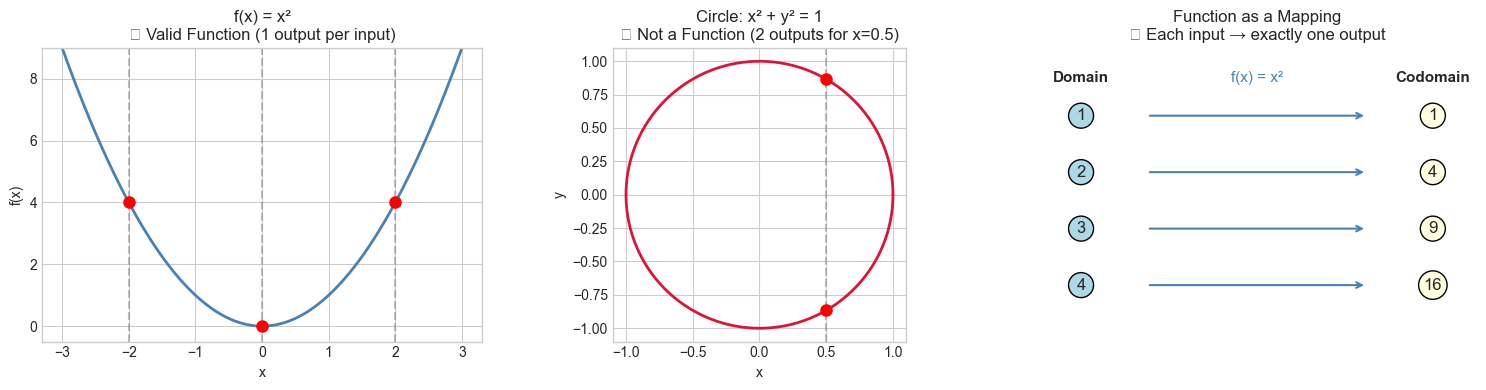

In [1]:
# --- Visualization: Valid vs Invalid Functions (vertical line test) ---
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

x = np.linspace(-3, 3, 400)

# --- Plot 1: Valid function f(x) = x^2 ---
axes[0].plot(x, x**2, color='steelblue', linewidth=2)
# Vertical line test: one intersection per vertical line
for xv in [-2, 0, 2]:
    axes[0].axvline(x=xv, color='gray', linestyle='--', alpha=0.5)
    y_val = xv**2
    axes[0].plot(xv, y_val, 'ro', markersize=8)
axes[0].set_title('f(x) = x²\n✓ Valid Function (1 output per input)')
axes[0].set_xlabel('x')
axes[0].set_ylabel('f(x)')
axes[0].set_ylim(-0.5, 9)

# --- Plot 2: Circle — NOT a function ---
theta = np.linspace(0, 2 * np.pi, 400)
cx, cy = np.cos(theta), np.sin(theta)
axes[1].plot(cx, cy, color='crimson', linewidth=2)
# Vertical line at x=0.5 hits circle twice
xv = 0.5
axes[1].axvline(x=xv, color='gray', linestyle='--', alpha=0.5)
y_vals = [np.sqrt(1 - xv**2), -np.sqrt(1 - xv**2)]
for yv in y_vals:
    axes[1].plot(xv, yv, 'ro', markersize=8)
axes[1].set_aspect('equal')
axes[1].set_title('Circle: x² + y² = 1\n✗ Not a Function (2 outputs for x=0.5)')
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')

# --- Plot 3: Function as a mapping diagram ---
axes[2].axis('off')
inputs = [1, 2, 3, 4]
outputs = [1, 4, 9, 16]  # f(x) = x^2
for i, (inp, out) in enumerate(zip(inputs, outputs)):
    y_pos = 1 - i * 0.25
    axes[2].text(0.1, y_pos, str(inp), ha='center', va='center',
                 bbox=dict(boxstyle='circle', facecolor='lightblue'), fontsize=12)
    axes[2].text(0.9, y_pos, str(out), ha='center', va='center',
                 bbox=dict(boxstyle='circle', facecolor='lightyellow'), fontsize=12)
    axes[2].annotate('', xy=(0.75, y_pos), xytext=(0.25, y_pos),
                     arrowprops=dict(arrowstyle='->', color='steelblue', lw=1.5))
axes[2].text(0.1, 1.15, 'Domain', ha='center', fontsize=11, fontweight='bold')
axes[2].text(0.9, 1.15, 'Codomain', ha='center', fontsize=11, fontweight='bold')
axes[2].text(0.5, 1.15, 'f(x) = x²', ha='center', fontsize=11, color='steelblue')
axes[2].set_title('Function as a Mapping\n✓ Each input → exactly one output')
axes[2].set_xlim(0, 1)
axes[2].set_ylim(0, 1.3)

plt.tight_layout()
plt.show()

---

## 4. Mathematical Formulation

**Formal definition:**

A function `f` from set `A` to set `B` is written:

```
f : A → B
```

where:
- `A` = domain (the set of all valid inputs)
- `B` = codomain (the set that outputs belong to)
- For every `x ∈ A`, there exists **exactly one** `y ∈ B` such that `f(x) = y`

The **range** (or image) is the subset of B that is actually produced: `{f(x) : x ∈ A}`.
The codomain is what outputs *could* be. The range is what they *actually are*.

**Vertical line test (for graphs):**
A curve in the xy-plane represents a function of x if and only if every vertical line `x = c` intersects the curve at most once.

In [2]:
# --- Mathematical Formulation: Checking the function property ---
# A mapping is a function if: for each input, there is EXACTLY ONE output.

def is_function(mapping: dict) -> bool:
    """
    Check if a dict-based mapping represents a valid function.
    
    A function requires each input maps to exactly one output.
    Since Python dicts enforce unique keys, any dict IS a valid function.
    But if we represent the mapping as a list of (input, output) pairs,
    we must check that no input maps to two different outputs.
    
    Args:
        mapping: list of (input, output) tuples
    Returns:
        True if valid function, False otherwise
    """
    seen = {}  # input -> output
    for x, y in mapping:
        if x in seen:
            if seen[x] != y:
                print(f"  Violation: input {x} maps to both {seen[x]} and {y}")
                return False
        else:
            seen[x] = y
    return True

# Test cases
valid_mapping = [(1, 1), (2, 4), (3, 9), (4, 16)]           # f(x) = x^2
invalid_mapping = [(1, 1), (2, 4), (2, 5), (3, 9)]          # 2 maps to both 4 and 5
many_to_one = [(1, 1), (2, 1), (3, 1), (4, 1)]              # all map to 1 — still valid!

print("valid_mapping (f(x) = x^2):", is_function(valid_mapping))    # True
print("invalid_mapping (2→4 and 2→5):", is_function(invalid_mapping))  # False
print("many_to_one (all→1):", is_function(many_to_one))              # True

# Key insight: many-to-one IS a valid function. One-to-many is NOT.

valid_mapping (f(x) = x^2): True
  Violation: input 2 maps to both 4 and 5
invalid_mapping (2→4 and 2→5): False
many_to_one (all→1): True


---

## 5. Python Implementation

In [3]:
# --- Implementation: Functions as first-class objects in Python ---
import numpy as np

# In Python, functions ARE first-class objects.
# You can pass them as arguments, store them, return them.
# This is the computational equivalent of the mathematical function concept.

def apply_function(f, x_values):
    """
    Apply a mathematical function f to an array of input values.
    
    Args:
        f: callable, a function from reals to reals
        x_values: np.ndarray, array of input values
    
    Returns:
        np.ndarray: array of output values f(x) for each x
    """
    return np.array([f(x) for x in x_values])

# Define three different functions — all represented the same way to the caller
def f_square(x):    return x ** 2
def f_cube(x):      return x ** 3
def f_abs(x):       return abs(x)

x_values = np.array([-3, -2, -1, 0, 1, 2, 3])

print("x:", x_values)
print("x²:", apply_function(f_square, x_values))
print("x³:", apply_function(f_cube, x_values))
print("|x|:", apply_function(f_abs, x_values))

# NumPy's vectorization is more efficient — but conceptually identical
# The formula changes; the structure (input → one output) stays the same.
print("\nWith NumPy vectorization (faster, same semantics):")
print("x²:", x_values ** 2)

x: [-3 -2 -1  0  1  2  3]
x²: [9 4 1 0 1 4 9]
x³: [-27  -8  -1   0   1   8  27]
|x|: [3 2 1 0 1 2 3]

With NumPy vectorization (faster, same semantics):
x²: [9 4 1 0 1 4 9]


---

## 6. Experiments

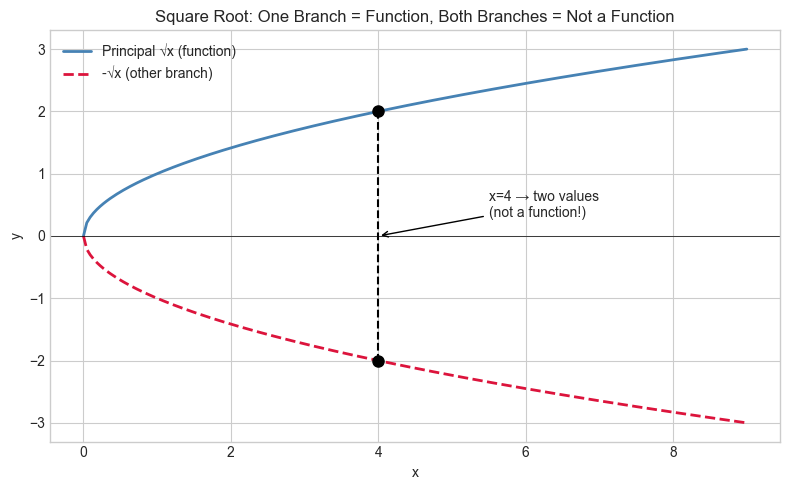

In [4]:
# --- Experiment 1: What makes something NOT a function? ---
# Hypothesis: multi-valued outputs violate the function property.
# Try: change which relation we test
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

# The square root has two values: sqrt(4) = +2 or -2.
# Principal sqrt (numpy) picks the positive branch — making it a function.
# If we take both branches, it's NOT a function.

x = np.linspace(0, 9, 200)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x, np.sqrt(x), color='steelblue', linewidth=2, label='Principal √x (function)')
ax.plot(x, -np.sqrt(x), color='crimson', linewidth=2, linestyle='--', label='-√x (other branch)')
ax.axhline(0, color='black', linewidth=0.5)

# Show that x=4 maps to two values if both branches included
ax.plot([4, 4], [2, -2], 'ko--', markersize=8)
ax.annotate('x=4 → two values\n(not a function!)', xy=(4, 0), xytext=(5.5, 0.3),
            arrowprops=dict(arrowstyle='->', color='black'))

ax.set_title('Square Root: One Branch = Function, Both Branches = Not a Function')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.legend()
plt.tight_layout()
plt.show()

# Try changing: plot x^(1/3) — is it a function? What about x^(1/2) for negative x?

In [5]:
# --- Experiment 2: Functions defined by tables (not formulas) ---
# Hypothesis: any consistent lookup table is a valid function.
# Try changing: add a conflict to the table and watch is_function fail.

# A real function with no closed-form formula: lookup table for a cipher
ROT13_MAP = {
    'a': 'n', 'b': 'o', 'c': 'p', 'd': 'q', 'e': 'r',
    'f': 's', 'g': 't', 'h': 'u', 'i': 'v', 'j': 'w',
    'k': 'x', 'l': 'y', 'm': 'z', 'n': 'a', 'o': 'b',
    'p': 'c', 'q': 'd', 'r': 'e', 's': 'f', 't': 'g',
    'u': 'h', 'v': 'i', 'w': 'j', 'x': 'k', 'y': 'l', 'z': 'm'
}

# This IS a function: each letter maps to exactly one letter
print("ROT13 is a function:")
msg = "hello"
encoded = "".join(ROT13_MAP[c] for c in msg)
print(f"  f('hello') = '{encoded}'")

# Applying twice returns original (it's its own inverse!)
decoded = "".join(ROT13_MAP[c] for c in encoded)
print(f"  f(f('hello')) = '{decoded}'")
# This property (f(f(x)) = x) is called an involution — reappears in ch055.

ROT13 is a function:
  f('hello') = 'uryyb'
  f(f('hello')) = 'hello'


---

## 7. Exercises

**Easy 1.** Which of the following relations are valid functions? Explain why or why not: (a) `{(1,2), (2,3), (3,4)}` (b) `{(1,2), (1,3), (2,4)}` (c) `{(1,1), (2,1), (3,1)}` *(Expected: yes, no, yes)*

**Easy 2.** Write a Python function `f` such that `f(0)=1`, `f(1)=2`, `f(2)=4`, `f(3)=8`. What mathematical operation does this represent? *(Expected: single line of code)*

**Medium 1.** The relation `y² = x` is NOT a function of x. But it can be split into two functions. Write both as Python functions and plot them together. What do they look like? *(Hint: think about what constraint separates them)*

**Medium 2.** Write a function `vertical_line_test(x_vals, y_vals, tolerance=1e-9)` that takes arrays of x and y coordinates (a curve sampled as points) and returns `True` if the curve passes the vertical line test. *(Hint: check for any duplicate x values with different y values)*

**Hard.** A **partial function** is defined on only a subset of its domain (e.g., `f(x) = 1/x` is undefined at `x=0`). Write a `SafeFunction` class that wraps any callable, defines a domain as a predicate (e.g., `lambda x: x != 0`), and raises a `DomainError` if called outside the domain. Test it with `f(x) = sqrt(x)` (domain: x ≥ 0) and `f(x) = log(x)` (domain: x > 0). *(Challenge: extend to handle numpy arrays, applying the function only where the predicate holds)*

---

## 8. Mini Project

In [ ]:
# --- Mini Project: Build a Function Registry ---
# Problem: In machine learning pipelines, we often apply different transformation
#          functions to different features. Build a registry that stores named
#          functions and applies them to data arrays.
# Dataset: Generated numerical data representing different feature types.
# Task: Build the registry, register several transformations, apply them, and
#       visualize the before/after distributions.

import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

class FunctionRegistry:
    """A named registry of transformation functions."""
    
    def __init__(self):
        self._registry = {}
    
    def register(self, name, fn):
        """Register a function under a name."""
        self._registry[name] = fn
        return self  # allow chaining
    
    def apply(self, name, x):
        """
        Apply a registered function to input x.
        Args:
            name: str, registered function name
            x: np.ndarray of input values
        Returns:
            np.ndarray of transformed values
        """
        if name not in self._registry:
            raise KeyError(f"No function registered as '{name}'")
        return self._registry[name](x)
    
    def list_functions(self):
        return list(self._registry.keys())

# --- Setup ---
np.random.seed(0)
registry = FunctionRegistry()

# Register standard ML feature transformations
registry.register('identity',   lambda x: x)
registry.register('square',     lambda x: x**2)
registry.register('log1p',      lambda x: np.log1p(np.abs(x)))  # log(1 + |x|)
registry.register('normalize',  lambda x: (x - x.mean()) / (x.std() + 1e-8))
registry.register('clip_upper', lambda x: np.minimum(x, np.percentile(x, 95)))

# Generate skewed feature data (common in real ML datasets)
raw_data = np.random.exponential(scale=2.0, size=1000)

# TODO: Apply all registered functions and plot the results
fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for ax, fn_name in zip(axes, registry.list_functions()):
    transformed = registry.apply(fn_name, raw_data)
    ax.hist(transformed, bins=40, color='steelblue', alpha=0.7, edgecolor='white')
    ax.set_title(f"f = '{fn_name}'")
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')

plt.suptitle('Effect of Different Function Transformations on Feature Distribution',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("Registered functions:", registry.list_functions())
print("\nExtension: Add 'sigmoid' and 'tanh' transformations and observe their effect.")

---

## 9. Chapter Summary & Connections

**What we covered:**
- A function is a mapping where each input produces exactly one output
- Functions are not just formulas — they can be tables, algorithms, or any deterministic rule
- The vertical line test is the geometric criterion for a valid function
- Python functions are first-class objects and directly correspond to mathematical functions
- Many-to-one is valid; one-to-many is not

**Backward connection:** This formalizes the intuition from ch003 (Abstraction) — a function is how we *abstract a relationship* between two quantities.

**Forward connections:**
- In ch053 (Domain and Range), we will make the input/output sets precise and explore what happens at the boundaries
- In ch054 (Function Composition), we will combine functions into pipelines — the mathematical equivalent of `f(g(x))`
- This concept will reappear in ch152 (Matrix Multiplication) where we see that a matrix *is* a linear function from one vector space to another

**Going deeper:** Tarski's fixed-point theorem, category theory (functions as morphisms), and lambda calculus formalize the function concept at a deeper level.